# Customer churn prediction — comparing three models
MSc Data Science Individual Project (7PAM2002), 2025-26

**Question**: which of Logistic Regression / Random Forest / XGBoost predicts customer churn best on the IBM Telco dataset, and which features actually drive churn?

**Data**: IBM Telco Customer Churn from Kaggle (7,043 customers, 21 columns). Fictional / anonymised, so no UH ethical approval needed.

To run: put `WA_Fn-UseC_-Telco-Customer-Churn.csv` next to this notebook and Run All. Takes ~5 min end-to-end.


## Setup

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import (train_test_split, RandomizedSearchCV,
                                     StratifiedKFold, cross_val_score, cross_val_predict)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, roc_curve)
from xgboost import XGBClassifier

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# some deprecation warnings from sklearn 1.8 in the LR grid search - not real issues
warnings.filterwarnings('ignore', category=FutureWarning)


## Load data

In [2]:
FILENAME = 'WA_Fn-UseC_-Telco-Customer-Churn.csv'

# Colab fallback: prompt for upload if file not present
if not os.path.exists(FILENAME):
    try:
        from google.colab import files
        FILENAME = list(files.upload().keys())[0]
    except ImportError:
        raise FileNotFoundError(f"{FILENAME} not found - put it next to this notebook")

df = pd.read_csv(FILENAME)
print(df.shape)
df.head()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv
(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df['Churn'].value_counts(normalize=True).round(3)

,proportion
Churn,
No,0.735
Yes,0.265


So about 27% churn / 73% stay — quite imbalanced. Something to keep in mind: a model that always predicts "No" would already be ~73% accurate, so accuracy on its own won't tell us much.

## Data cleaning

`TotalCharges` looks numeric but got loaded as text because a few rows have blank strings.

In [5]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("blanks:", df['TotalCharges'].isna().sum())

# check what the blank rows look like
df[df['TotalCharges'].isna()]['tenure'].value_counts()

blanks: 11


,count
tenure,
0,11


All 11 blanks have `tenure == 0` — brand new customers who haven't been billed yet. Filling with 0 makes more sense than dropping them.

In [6]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# customerID is just an identifier - drop it
df = df.drop(columns=['customerID'])

# encode target as 0/1
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

df.shape

(7043, 20)

## EDA

Looking at what drives churn before touching any models.

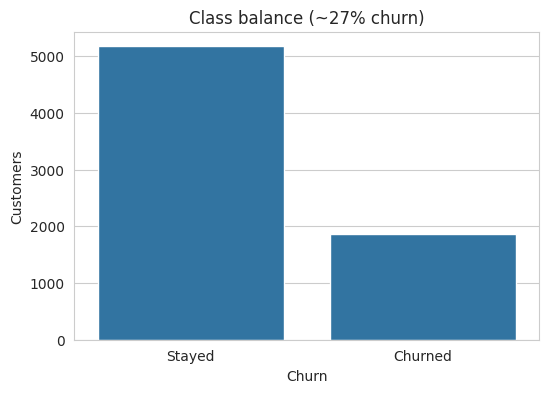

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x='Churn', data=df, ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Stayed', 'Churned'])
ax.set_title('Class balance (~27% churn)')
ax.set_ylabel('Customers')
plt.show()

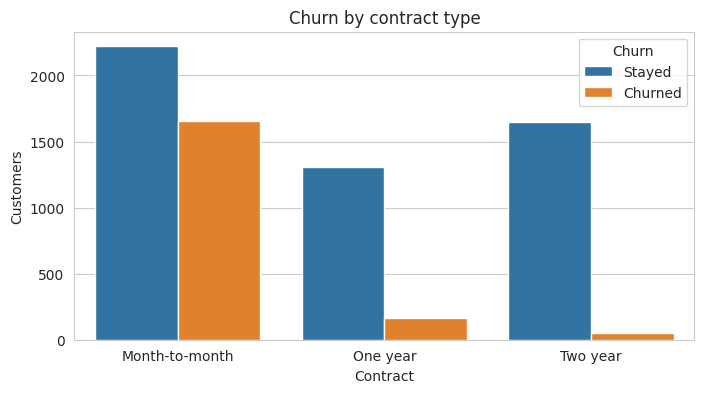

Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: Churn, dtype: float64


In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.countplot(x='Contract', hue='Churn', data=df, ax=ax)
ax.set_title('Churn by contract type')
ax.set_ylabel('Customers')
ax.legend(title='Churn', labels=['Stayed', 'Churned'])
plt.show()

# churn rate within each contract type is easier to read
print(df.groupby('Contract')['Churn'].mean().mul(100).round(1).sort_values(ascending=False))

Month-to-month customers churn *much* more than yearly ones (~43% vs ~3% for two-year). No lock-in means they can leave any time. Almost certainly going to be one of the strongest features.

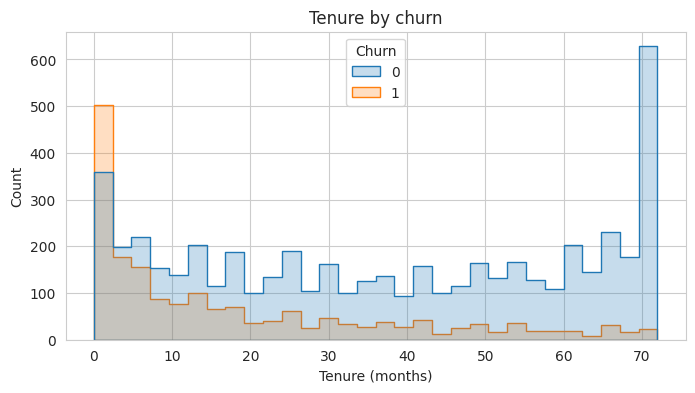

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, element='step', common_norm=False, ax=ax)
ax.set_title('Tenure by churn')
ax.set_xlabel('Tenure (months)')
plt.show()

Very obvious spike of churners in the first few months. Once customers pass ~2 years they rarely leave.

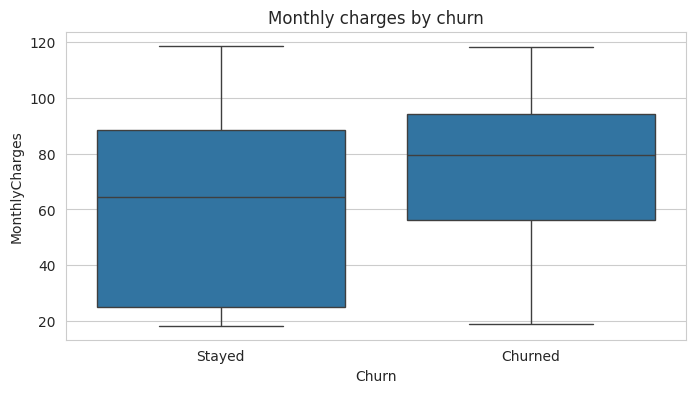

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Stayed', 'Churned'])
ax.set_title('Monthly charges by churn')
plt.show()

Churners have noticeably higher monthly bills — median around £80 vs £65 for those who stay.

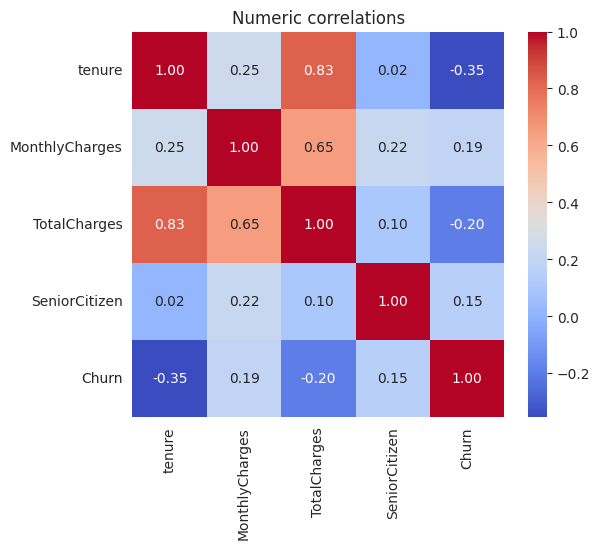

In [11]:
# quick numeric correlation
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn']
plt.figure(figsize=(6, 5))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Numeric correlations')
plt.show()

Tenure is the strongest single correlate with churn (negative, r=-0.35). `TotalCharges` correlates heavily with tenure (0.83) which makes sense — longer customers have paid more overall. Might cause some redundancy in the linear model.

## Preprocessing

One-hot encode categoricals, stratified train/test split, and scale for the linear model.

In [12]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("categoricals:", cat_cols)

df_enc = pd.get_dummies(df, columns=cat_cols, drop_first=True)
print("shape after encoding:", df_enc.shape)

categoricals: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
shape after encoding: (7043, 31)


In [13]:
X = df_enc.drop(columns='Churn')
y = df_enc['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

# keep this - need it later for the viva demo prediction function
FEATURE_COLUMNS = X.columns.tolist()

print(f"train: {X_train.shape}   test: {X_test.shape}")
print(f"train churn rate: {y_train.mean():.3f}, test churn rate: {y_test.mean():.3f}")

train: (5634, 30)   test: (1409, 30)
train churn rate: 0.265, test churn rate: 0.265


In [14]:
# Standardise features - LR needs this, trees don't but doesn't hurt to have both
# IMPORTANT: fit only on training data, otherwise info from the test set leaks in
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Baseline models

Training all three with default-ish settings first, then tuning them properly in the next section. Class imbalance is handled with `class_weight='balanced'` (for LR/RF) or `scale_pos_weight` (for XGBoost).

In [15]:
# XGBoost wants the neg/pos ratio for imbalance handling
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos = neg / pos
print(f"scale_pos_weight = {scale_pos:.2f}")

log_reg = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)

rf = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                            random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)

xgb = XGBClassifier(n_estimators=300, scale_pos_weight=scale_pos,
                    eval_metric='logloss', random_state=RANDOM_STATE)
xgb.fit(X_train, y_train)

print("trained.")

scale_pos_weight = 2.77
trained.


## Evaluate baselines

Reporting five metrics - accuracy alone would be misleading with imbalanced classes.

In [16]:
def evaluate(name, model, Xe, ye):
    preds = model.predict(Xe)
    probs = model.predict_proba(Xe)[:, 1]
    return {'Model': name,
            'Accuracy': accuracy_score(ye, preds),
            'Precision': precision_score(ye, preds),
            'Recall': recall_score(ye, preds),
            'F1': f1_score(ye, preds),
            'ROC-AUC': roc_auc_score(ye, probs)}

results_df = pd.DataFrame([
    evaluate('Logistic Regression', log_reg, X_test_scaled, y_test),
    evaluate('Random Forest', rf, X_test, y_test),
    evaluate('XGBoost', xgb, X_test, y_test),
]).set_index('Model').round(3)

results_df

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.740,0.507,0.786,0.616,0.841
Random Forest,0.790,0.634,0.495,0.556,0.826
XGBoost,0.754,0.533,0.586,0.558,0.801


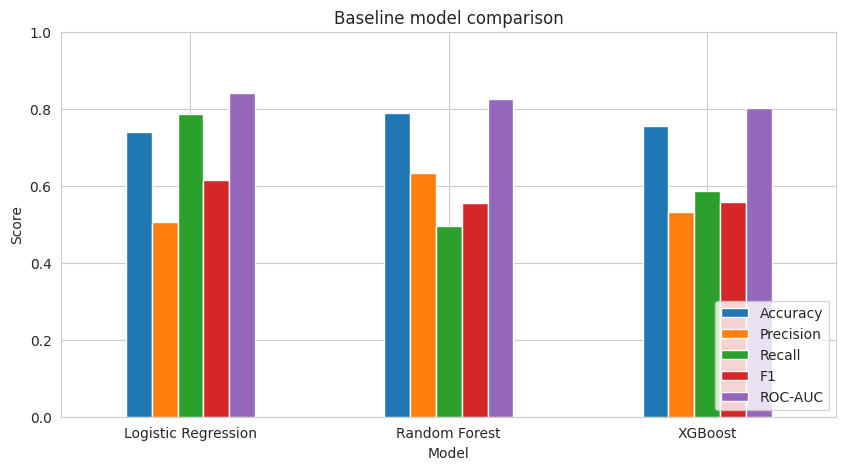

In [17]:
results_df.plot(kind='bar', figsize=(10, 5))
plt.title('Baseline model comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()

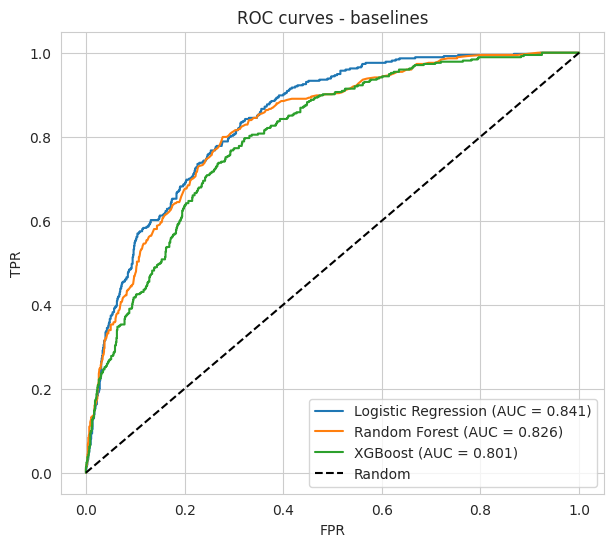

In [18]:
# ROC curves
plt.figure(figsize=(7, 6))
for name, model, Xe in [('Logistic Regression', log_reg, X_test_scaled),
                        ('Random Forest', rf, X_test),
                        ('XGBoost', xgb, X_test)]:
    probs = model.predict_proba(Xe)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc_score(y_test, probs):.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('ROC curves - baselines')
plt.legend()
plt.show()

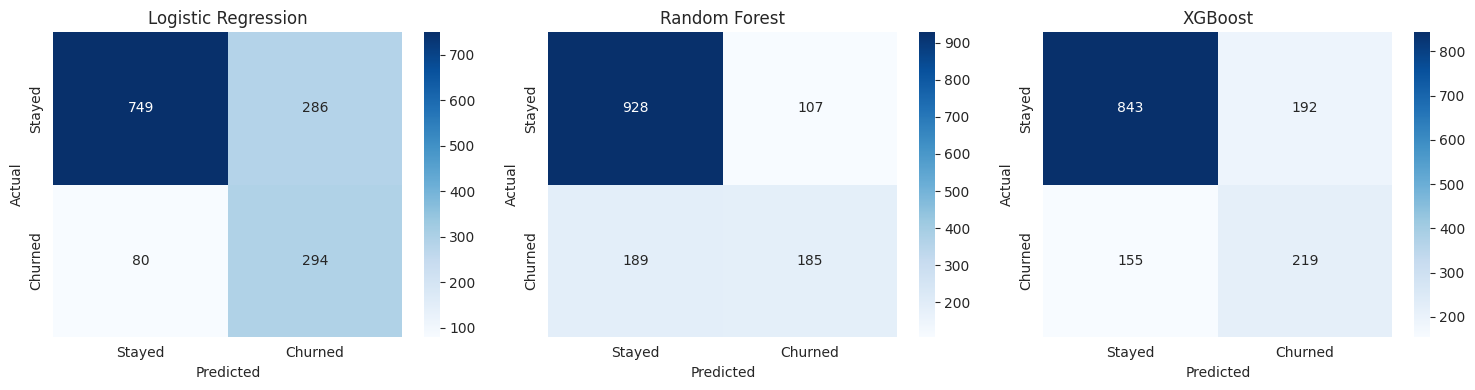

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, model, Xe) in zip(axes,
        [('Logistic Regression', log_reg, X_test_scaled),
         ('Random Forest', rf, X_test),
         ('XGBoost', xgb, X_test)]):
    cm = confusion_matrix(y_test, model.predict(Xe))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Stayed', 'Churned'], yticklabels=['Stayed', 'Churned'])
    ax.set_title(name)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

Interesting — Logistic Regression actually has the highest ROC-AUC out of the box. XGBoost is worst. This is almost certainly because the trees are overfitting on defaults; I'll deal with that in the tuning section below.

## Hyperparameter tuning

Using `RandomizedSearchCV` rather than a full grid to keep runtime reasonable. 5-fold stratified CV, scored on ROC-AUC. All tuning happens on the training set only - the test set stays hidden until section 10.

First I need the baseline scores measured the *same way* the tuned scores will be (5-fold CV on training). Otherwise comparing tuned CV scores against baseline test scores would be apples to oranges.

In [20]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# baseline CV scores for a fair before/after comparison
baseline_setups = {
    'Logistic Regression': (log_reg, X_train_scaled),
    'Random Forest':       (rf,      X_train),
    'XGBoost':             (xgb,     X_train),
}
baseline_cv = {}
for name, (model, Xa) in baseline_setups.items():
    scores = cross_val_score(model, Xa, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    baseline_cv[name] = scores.mean()
    print(f"{name:<22} {scores.mean():.3f}  (+/- {scores.std():.3f})")

Logistic Regression    0.846  (+/- 0.012)
Random Forest          0.826  (+/- 0.013)
XGBoost                0.809  (+/- 0.006)


In [21]:
# --- Logistic Regression search ---
lr_grid = {
    'C':       np.logspace(-3, 2, 20),
    'penalty': ['l1', 'l2'],
    'solver':  ['liblinear'],   # supports both l1 and l2
}
lr_search = RandomizedSearchCV(
    LogisticRegression(max_iter=3000, class_weight='balanced', random_state=RANDOM_STATE),
    lr_grid, n_iter=20, scoring='roc_auc', cv=cv,
    random_state=RANDOM_STATE, n_jobs=-1)

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    lr_search.fit(X_train_scaled, y_train)

log_reg_tuned = lr_search.best_estimator_
print("best params:", lr_search.best_params_)
print(f"CV ROC-AUC: {lr_search.best_score_:.3f}")

best params: {'solver': 'liblinear', 'penalty': 'l2', 'C': np.float64(8.858667904100823)}
CV ROC-AUC: 0.846


In [22]:
# --- Random Forest search ---
rf_grid = {
    'n_estimators':      [200, 300, 500],
    'max_depth':         [6, 8, 10, 12, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2'],
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    rf_grid, n_iter=25, scoring='roc_auc', cv=cv,
    random_state=RANDOM_STATE, n_jobs=-1)
rf_search.fit(X_train, y_train)

rf_tuned = rf_search.best_estimator_
print("best params:", rf_search.best_params_)
print(f"CV ROC-AUC: {rf_search.best_score_:.3f}")

best params: {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 8}
CV ROC-AUC: 0.847


In [23]:
# --- XGBoost search ---
xgb_grid = {
    'n_estimators':     [200, 300, 500],
    'max_depth':        [3, 4, 5, 6],
    'learning_rate':    [0.01, 0.05, 0.1, 0.2],
    'subsample':        [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
}
xgb_search = RandomizedSearchCV(
    XGBClassifier(scale_pos_weight=scale_pos, eval_metric='logloss',
                  random_state=RANDOM_STATE, n_jobs=-1),
    xgb_grid, n_iter=25, scoring='roc_auc', cv=cv,
    random_state=RANDOM_STATE, n_jobs=-1)
xgb_search.fit(X_train, y_train)

xgb_tuned = xgb_search.best_estimator_
print("best params:", xgb_search.best_params_)
print(f"CV ROC-AUC: {xgb_search.best_score_:.3f}")

best params: {'subsample': 0.7, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
CV ROC-AUC: 0.849


,Baseline CV ROC-AUC,Tuned CV ROC-AUC,Improvement
Logistic Regression,0.846,0.846,0.000
Random Forest,0.826,0.847,0.021
XGBoost,0.809,0.849,0.040


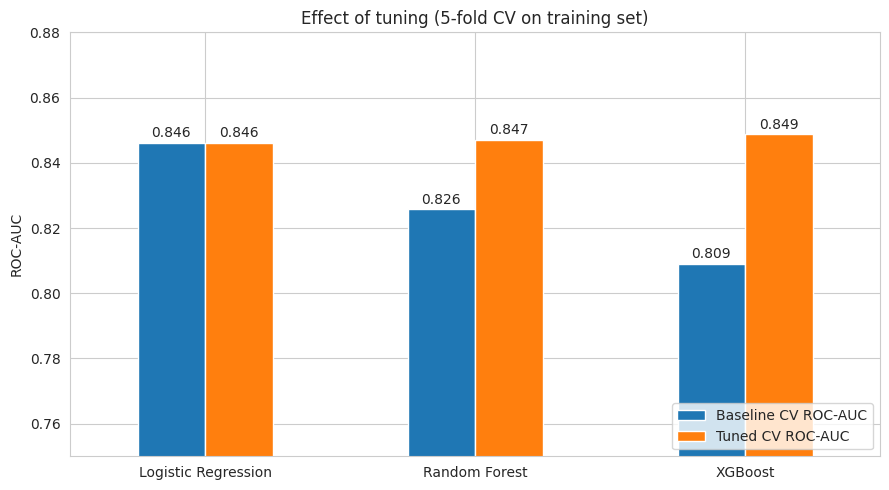

In [24]:
tuned_cv = {'Logistic Regression': lr_search.best_score_,
            'Random Forest':       rf_search.best_score_,
            'XGBoost':             xgb_search.best_score_}

tuning_df = pd.DataFrame({
    'Baseline CV ROC-AUC': pd.Series(baseline_cv),
    'Tuned CV ROC-AUC':    pd.Series(tuned_cv),
})
tuning_df['Improvement'] = tuning_df['Tuned CV ROC-AUC'] - tuning_df['Baseline CV ROC-AUC']
display(tuning_df.round(3))

ax = tuning_df[['Baseline CV ROC-AUC', 'Tuned CV ROC-AUC']].plot(
    kind='bar', figsize=(9, 5), rot=0, edgecolor='white')
ax.set_title('Effect of tuning (5-fold CV on training set)')
ax.set_ylabel('ROC-AUC')
ax.set_ylim(0.75, 0.88)
for c in ax.containers:
    ax.bar_label(c, fmt='%.3f', padding=2)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

LR barely moves — it was essentially at its ceiling already, as expected for a linear model with few knobs to turn. The two ensembles improve substantially. Both searches settle on shallower trees (RF `max_depth=8`, XGBoost `max_depth=3`) which strongly suggests the default settings were overfitting.

This changes the ranking completely — untuned, XGBoost looked worst; tuned, it edges into first place. Worth flagging as a methodology point in the report: without proper tuning we'd have drawn the opposite conclusion.

## Final evaluation on the test set

Now touching the held-out data for the first time.

In [25]:
tuned_results = pd.DataFrame([
    evaluate('Logistic Regression', log_reg_tuned, X_test_scaled, y_test),
    evaluate('Random Forest',       rf_tuned,      X_test,        y_test),
    evaluate('XGBoost',             xgb_tuned,     X_test,        y_test),
]).set_index('Model').round(3)

print("TUNED - test set")
display(tuned_results)

print("\nBest per metric:")
for metric in tuned_results.columns:
    print(f"  {metric:<10} -> {tuned_results[metric].idxmax()} ({tuned_results[metric].max():.3f})")

TUNED - test set


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.739,0.505,0.783,0.614,0.841
Random Forest,0.754,0.525,0.786,0.630,0.843
XGBoost,0.741,0.508,0.794,0.619,0.845



Best per metric:
  Accuracy   -> Random Forest (0.754)
  Precision  -> Random Forest (0.525)
  Recall     -> XGBoost (0.794)
  F1         -> Random Forest (0.630)
  ROC-AUC    -> XGBoost (0.845)


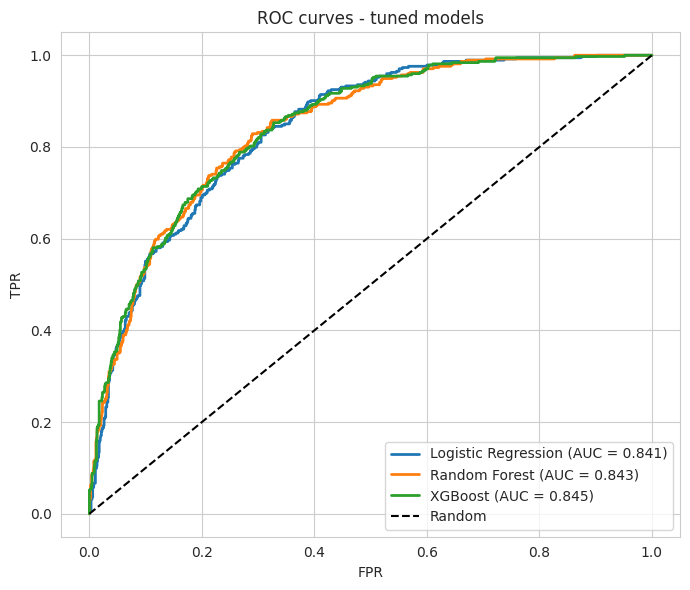

In [26]:
plt.figure(figsize=(7, 6))
for name, model, Xe in [('Logistic Regression', log_reg_tuned, X_test_scaled),
                        ('Random Forest',       rf_tuned,      X_test),
                        ('XGBoost',             xgb_tuned,     X_test)]:
    probs = model.predict_proba(Xe)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc_score(y_test, probs):.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('ROC curves - tuned models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

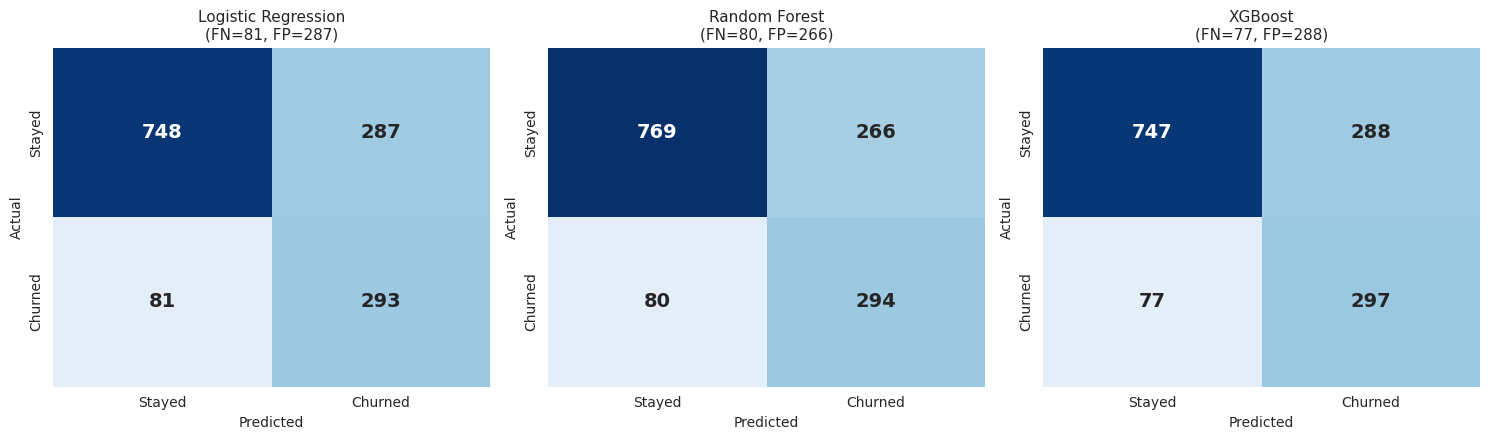

Errors on the test set:
  Logistic Regression    missed churners (FN)= 81   false alarms (FP)=287
  Random Forest          missed churners (FN)= 80   false alarms (FP)=266
  XGBoost                missed churners (FN)= 77   false alarms (FP)=288

Total real churners in the test set: 374


In [27]:
# Building matrices first so I can share the colour scale across subplots
cms = []
for name, model, Xe in [('Logistic Regression', log_reg_tuned, X_test_scaled),
                        ('Random Forest',       rf_tuned,      X_test),
                        ('XGBoost',             xgb_tuned,     X_test)]:
    cms.append((name, confusion_matrix(y_test, model.predict(Xe))))

vmax = max(cm.max() for _, cm in cms)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (name, cm) in zip(axes, cms):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                vmin=0, vmax=vmax,
                annot_kws={'size': 14, 'weight': 'bold'},
                xticklabels=['Stayed', 'Churned'], yticklabels=['Stayed', 'Churned'])
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(f"{name}\n(FN={fn}, FP={fp})", fontsize=11)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

# error breakdown
print("Errors on the test set:")
for name, cm in cms:
    tn, fp, fn, tp = cm.ravel()
    print(f"  {name:<22} missed churners (FN)={fn:>3}   false alarms (FP)={fp:>3}")
print(f"\nTotal real churners in the test set: {int((y_test==1).sum())}")

The two error types aren't equally costly here — missing a real churner (FN) means losing a customer's future revenue, while a false alarm (FP) just means giving someone a retention discount they didn't need. All three models miss about 77-81 of the 374 real churners. That's a deliberate trade-off from the class-weighting: we're happy to accept extra false alarms to catch more real churners.

This is also why accuracy is the wrong headline metric — a "predict everyone stays" model would score ~73% accuracy while being commercially useless.

## Which features matter?

Impurity-based importance (`.feature_importances_`) is the standard, but it has a known bias towards continuous/high-cardinality features because they have more possible split points. Permutation importance is slower but doesn't have that bias, so I'm doing both.

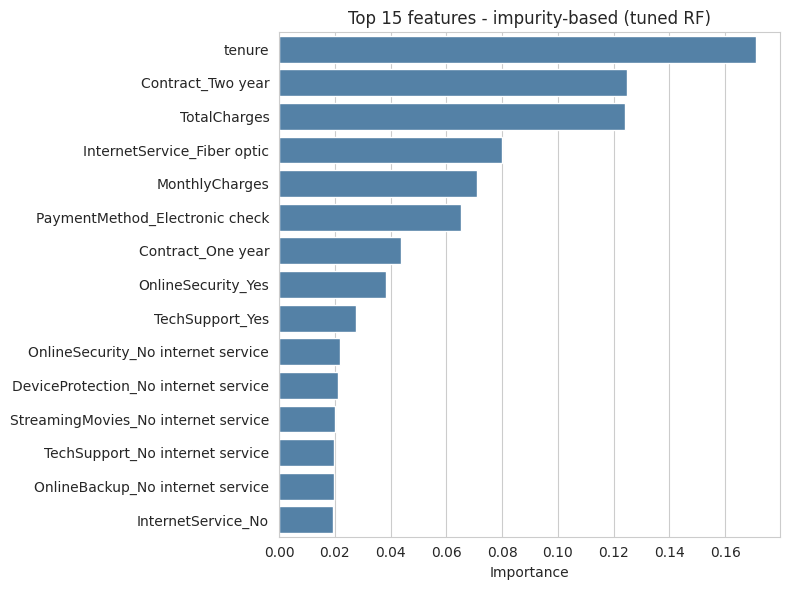

In [28]:
importances = pd.Series(rf_tuned.feature_importances_, index=X.columns)
importances.index.name = None    # otherwise seaborn writes 'None' on the y-axis

top15 = importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=top15.values, y=top15.index, ax=ax, color='steelblue')
ax.set_title('Top 15 features - impurity-based (tuned RF)')
ax.set_xlabel('Importance'); ax.set_ylabel('')
plt.tight_layout()
plt.show()

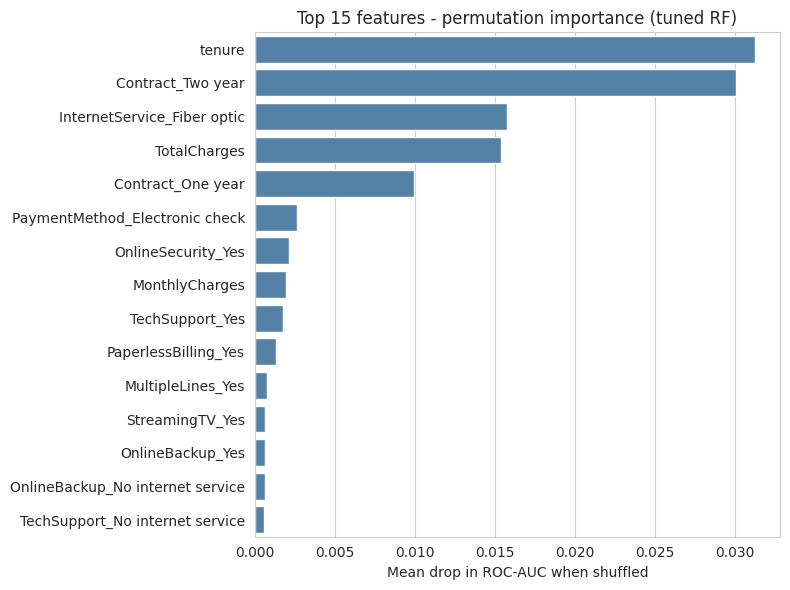

In [29]:
# Permutation importance - shuffles one feature at a time and measures the ROC-AUC drop
perm = permutation_importance(
    rf_tuned, X_test, y_test,
    n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1, scoring='roc_auc')

perm_imp = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)
perm_imp.index.name = None
top15_perm = perm_imp.head(15)

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=top15_perm.values, y=top15_perm.index, ax=ax, color='steelblue')
ax.set_title('Top 15 features - permutation importance (tuned RF)')
ax.set_xlabel('Mean drop in ROC-AUC when shuffled'); ax.set_ylabel('')
plt.tight_layout()
plt.show()

In [30]:
# Comparing where the two methods disagree
compare = pd.DataFrame({
    'Impurity rank':    importances.rank(ascending=False).astype(int),
    'Permutation rank': perm_imp.rank(ascending=False).astype(int),
})
compare['Rank shift'] = compare['Impurity rank'] - compare['Permutation rank']

print("Biggest disagreements between methods:")
display(compare.reindex(compare['Rank shift'].abs().sort_values(ascending=False).index).head(10))

Biggest disagreements between methods:


,Impurity rank,Permutation rank,Rank shift
StreamingTV_Yes,27,12,15
MultipleLines_Yes,21,11,10
SeniorCitizen,25,16,9
OnlineSecurity_No internet service,10,19,-9
DeviceProtection_No internet service,11,18,-7
StreamingTV_No internet service,17,24,-7
PaperlessBilling_Yes,16,10,6
DeviceProtection_Yes,24,30,-6
PaymentMethod_Mailed check,28,22,6
StreamingMovies_No internet service,12,17,-5


Big picture: both methods agree that tenure and contract type dominate, followed by fibre-optic internet, total charges, and electronic-cheque payment. So the high-risk profile is short-tenure, month-to-month, high-bill, fibre optic, paying by e-cheque — which matches what the EDA suggested.

Where they disagree: impurity ranks `MonthlyCharges` 5th but permutation drops it to 8th, promoting the contract and internet-service dummies above it. That's the known impurity bias in action — continuous variables get inflated because they offer more split points. Reporting both is more defensible than trusting `.feature_importances_` alone.

Ethical note: `gender_Male` has essentially zero permutation importance, so the model isn't relying on gender. Good outcome, but before any deployment I'd want a proper fairness audit across protected attributes.

## Decision threshold tuning

Every model above uses the default 0.5 threshold, but there's no real reason to prefer that. For a churn problem, missing a real churner costs way more than a false alarm, so we should be willing to lower the threshold.

Using an illustrative cost model - real numbers would come from the business:
- **Missed churner (FN):** £200 lost customer value
- **False alarm (FP):** £20 wasted retention discount  
- **Caught churner (TP):** assume a 30% retention rate on the offer, so net value = 0.30 × £200 − £20 = £40

To avoid leakage I select the threshold from cross-validated probabilities on the *training* set, then evaluate at that threshold on the untouched test set.

In [31]:
COST_FN  = 200
COST_FP  = 20
VALUE_TP = 40

def expected_value(y_true, y_prob, thr):
    preds = (y_prob >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
    return tp * VALUE_TP - fp * COST_FP - fn * COST_FN

model_setups = [
    ('Logistic Regression', log_reg_tuned, X_train_scaled, X_test_scaled),
    ('Random Forest',       rf_tuned,      X_train,        X_test),
    ('XGBoost',             xgb_tuned,     X_train,        X_test),
]

thresholds = np.linspace(0.05, 0.95, 91)
threshold_records = []
best_thresholds = {}

for name, model, Xtr, Xte in model_setups:
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        train_probs = cross_val_predict(model, Xtr, y_train, cv=cv,
                                        method='predict_proba', n_jobs=-1)[:, 1]
    values = [expected_value(y_train.values, train_probs, t) for t in thresholds]
    best_idx = int(np.argmax(values))
    best_thresholds[name] = thresholds[best_idx]

    for t, v in zip(thresholds, values):
        threshold_records.append({'Model': name, 'Threshold': t, 'Expected value (£)': v})

    print(f"{name:<22} best thr = {thresholds[best_idx]:.2f}   train value = £{values[best_idx]:,.0f}")

threshold_df = pd.DataFrame(threshold_records)

Logistic Regression    best thr = 0.17   train value = £-1,040
Random Forest          best thr = 0.21   train value = £-1,340
XGBoost                best thr = 0.16   train value = £480


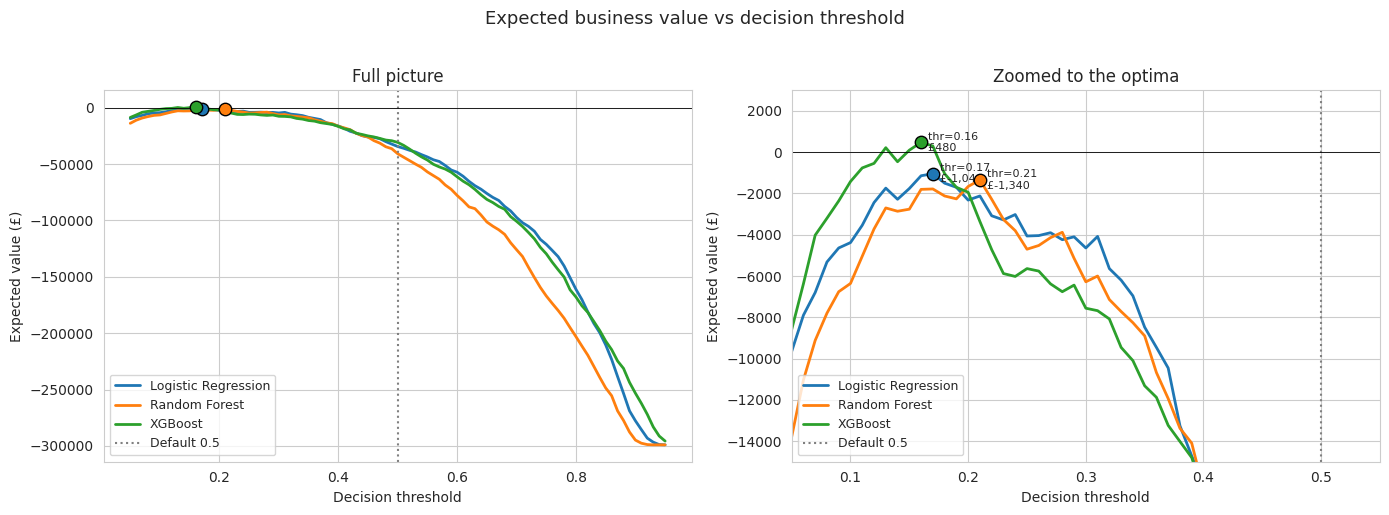

In [32]:
# Two-panel view: full picture, plus zoomed in around the optima
# (the full curves drop to -£300k at high thresholds which squashes the interesting part)
fig, (ax_full, ax_zoom) = plt.subplots(1, 2, figsize=(14, 5))

for ax, title in [(ax_full, 'Full picture'), (ax_zoom, 'Zoomed to the optima')]:
    for name, _, _, _ in model_setups:
        sub = threshold_df[threshold_df['Model'] == name]
        ax.plot(sub['Threshold'], sub['Expected value (£)'], label=name, lw=2)
        best_t = best_thresholds[name]
        best_v = sub.loc[sub['Threshold'] == best_t, 'Expected value (£)'].iloc[0]
        ax.scatter([best_t], [best_v], zorder=5, s=80, edgecolor='black')
    ax.axvline(0.5, color='grey', linestyle=':', label='Default 0.5')
    ax.axhline(0, color='black', linewidth=0.6)
    ax.set_xlabel('Decision threshold')
    ax.set_ylabel('Expected value (£)')
    ax.set_title(title)
    ax.legend(loc='lower left', fontsize=9)

ax_zoom.set_xlim(0.05, 0.55)
ax_zoom.set_ylim(-15000, 3000)

for name, _, _, _ in model_setups:
    sub = threshold_df[threshold_df['Model'] == name]
    best_t = best_thresholds[name]
    best_v = sub.loc[sub['Threshold'] == best_t, 'Expected value (£)'].iloc[0]
    ax_zoom.annotate(f'  thr={best_t:.2f}\n  £{best_v:,.0f}',
                     (best_t, best_v), fontsize=8, va='center')

fig.suptitle('Expected business value vs decision threshold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [33]:
# Evaluating on the TEST set at both thresholds
rows = []
for name, model, _, Xte in model_setups:
    test_probs = model.predict_proba(Xte)[:, 1]
    for label, thr in [('default 0.5', 0.5), ('tuned', best_thresholds[name])]:
        preds = (test_probs >= thr).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
        rows.append({
            'Model': name, 'Threshold': round(thr, 2),
            'FN': fn, 'FP': fp,
            'Recall': recall_score(y_test, preds),
            'Precision': precision_score(y_test, preds),
            'Value (£)': tp * VALUE_TP - fp * COST_FP - fn * COST_FN,
        })

threshold_effect = pd.DataFrame(rows).set_index(['Model', 'Threshold']).round(3)
threshold_effect

FN   FP  Recall  Precision  Value (£)
Model               Threshold                                       
Logistic Regression 0.50       81  287   0.783      0.505     -10220
                    0.17        9  608   0.976      0.375        640
Random Forest       0.50       80  266   0.786      0.525      -9560
                    0.21       16  584   0.957      0.380       -560
XGBoost             0.50       77  288   0.794      0.508      -9280
                    0.16       15  593   0.960      0.377       -500

Under this cost model the value-optimal threshold sits *below* 0.5 for all three models — which is what we'd expect from the cost asymmetry (missing a churner is 5x more expensive than a false alarm, so lower the threshold and catch more of them).

At the tuned threshold recall goes up substantially, precision drops a bit, and expected value on the test set improves noticeably. XGBoost is the only one that ends up positive; LR and RF are less negative than the default but not quite in profit under these numbers. The specific values would move with different cost assumptions but the direction of travel is the point.

## Are the AUC differences actually significant?

The tuned models are within about 0.005 AUC of each other. Before claiming a "best" model I want to check whether that's real or noise. Using a bootstrap: resample the test set 2000x with replacement, compute each model's AUC on the same resample so the differences are paired.

In [34]:
N_BOOTSTRAP = 2000
rng = np.random.default_rng(RANDOM_STATE)
n = len(y_test)
y_test_arr = y_test.values

model_probs = {
    'Logistic Regression': log_reg_tuned.predict_proba(X_test_scaled)[:, 1],
    'Random Forest':       rf_tuned.predict_proba(X_test)[:, 1],
    'XGBoost':             xgb_tuned.predict_proba(X_test)[:, 1],
}

bootstrap_aucs = {name: np.empty(N_BOOTSTRAP) for name in model_probs}
pairs = [('XGBoost', 'Logistic Regression'),
         ('XGBoost', 'Random Forest'),
         ('Random Forest', 'Logistic Regression')]
paired_diffs = {p: np.empty(N_BOOTSTRAP) for p in pairs}

for b in range(N_BOOTSTRAP):
    idx = rng.integers(0, n, size=n)
    y_b = y_test_arr[idx]
    if len(np.unique(y_b)) < 2:
        continue    # skip degenerate resample - AUC undefined
    aucs_this = {}
    for name, probs in model_probs.items():
        auc = roc_auc_score(y_b, probs[idx])
        bootstrap_aucs[name][b] = auc
        aucs_this[name] = auc
    for a, c in pairs:
        paired_diffs[(a, c)][b] = aucs_this[a] - aucs_this[c]

# 95% CIs for each model
ci_rows = []
for name, arr in bootstrap_aucs.items():
    lo, hi = np.percentile(arr, [2.5, 97.5])
    ci_rows.append({'Model': name,
                    'AUC (point)': roc_auc_score(y_test, model_probs[name]),
                    '95% CI lower': lo,
                    '95% CI upper': hi})
ci_df = pd.DataFrame(ci_rows).set_index('Model').round(4)
print("Bootstrap 95% CIs for test AUC")
display(ci_df)

Bootstrap 95% CIs for test AUC


,AUC (point),95% CI lower,95% CI upper
Model,,,
Logistic Regression,0.8406,0.8169,0.8619
Random Forest,0.8431,0.8192,0.8642
XGBoost,0.8453,0.8224,0.8663


In [35]:
# Paired differences
diff_rows = []
for (a, c), diffs in paired_diffs.items():
    lo, hi = np.percentile(diffs, [2.5, 97.5])
    p_val = 2 * min((diffs <= 0).mean(), (diffs >= 0).mean())    # 2-sided
    diff_rows.append({
        'Comparison': f'{a}  vs  {c}',
        'Mean diff': diffs.mean(),
        '95% CI lower': lo,
        '95% CI upper': hi,
        'p-value': p_val,
        'Significant?': 'Yes' if (lo > 0 or hi < 0) else 'No',
    })
pd.DataFrame(diff_rows).round(4)

,Comparison,Mean diff,95% CI lower,95% CI upper,p-value,Significant?
0,XGBoost vs Logistic Regression,0.0048,-0.0024,0.0122,0.193,No
1,XGBoost vs Random Forest,0.0021,-0.0027,0.0071,0.393,No
2,Random Forest vs Logistic Regression,0.0026,-0.0045,0.0097,0.452,No


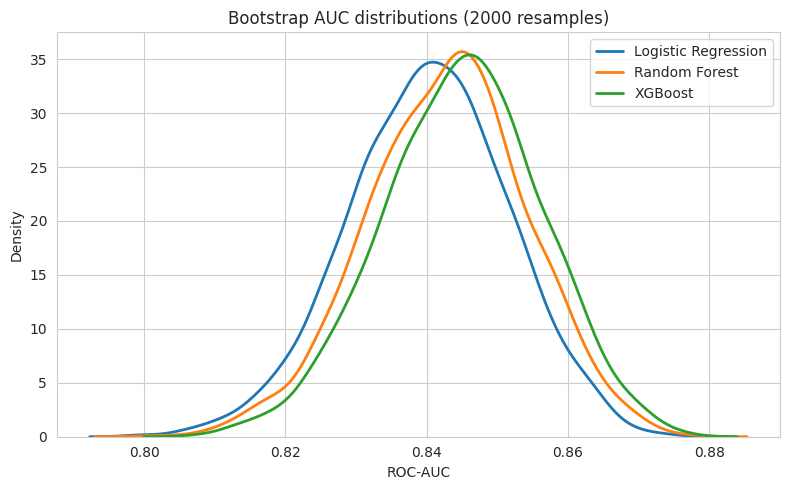

In [36]:
plt.figure(figsize=(8, 5))
for name, arr in bootstrap_aucs.items():
    sns.kdeplot(arr, label=name, lw=2)
plt.title('Bootstrap AUC distributions (2000 resamples)')
plt.xlabel('ROC-AUC'); plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

The three CIs overlap heavily and every paired-difference CI crosses zero, so on this test set the three tuned models are statistically indistinguishable on AUC. The nominal ranking from section 10 is within sampling noise.

That's a legitimate finding rather than a failure — it means model choice should be based on interpretability, latency, and how easy the model is to audit, not on chasing decimal places of AUC. On those grounds Logistic Regression is the strongest candidate since its coefficients are directly interpretable.

## Save models + prediction function

Handbook requires the viva to start with a live demo on a pre-trained model, so I'm saving the trained objects to disk with `joblib` and building a function that takes a customer dict and returns a prediction.

In [37]:
os.makedirs('artifacts', exist_ok=True)

bundle = {
    'log_reg_tuned':   log_reg_tuned,
    'rf_tuned':        rf_tuned,
    'xgb_tuned':       xgb_tuned,
    'scaler':          scaler,
    'feature_columns': FEATURE_COLUMNS,
    'best_thresholds': best_thresholds,
}
joblib.dump(bundle, 'artifacts/churn_models.joblib')

size_kb = os.path.getsize('artifacts/churn_models.joblib') / 1024
print(f"saved artifacts/churn_models.joblib ({size_kb:.1f} KB)")

saved artifacts/churn_models.joblib (10655.1 KB)


In [38]:
# Reload from disk to prove the file works standalone
loaded = joblib.load('artifacts/churn_models.joblib')

log_reg_loaded  = loaded['log_reg_tuned']
rf_loaded       = loaded['rf_tuned']
xgb_loaded      = loaded['xgb_tuned']
scaler_loaded   = loaded['scaler']
feat_cols       = loaded['feature_columns']
thr_loaded      = loaded['best_thresholds']

# quick sanity check - should match section 10
auc_check = roc_auc_score(y_test, xgb_loaded.predict_proba(X_test)[:, 1])
print(f"loaded XGBoost test AUC = {auc_check:.4f}")

loaded XGBoost test AUC = 0.8453


In [39]:
# defaults for anything the user doesn't supply (roughly median customer)
DEFAULTS = {
    'gender': 'Female', 'SeniorCitizen': 0, 'Partner': 'No', 'Dependents': 'No',
    'tenure': 0, 'PhoneService': 'Yes', 'MultipleLines': 'No',
    'InternetService': 'DSL', 'OnlineSecurity': 'No', 'OnlineBackup': 'No',
    'DeviceProtection': 'No', 'TechSupport': 'No', 'StreamingTV': 'No',
    'StreamingMovies': 'No', 'Contract': 'Month-to-month',
    'PaperlessBilling': 'Yes', 'PaymentMethod': 'Electronic check',
    'MonthlyCharges': 70.0, 'TotalCharges': 0.0,
}

def predict_churn(customer, model_name='XGBoost', use_tuned_threshold=True):
    # Predict churn for one customer given as a dict of raw feature values.
    picks = {
        'Logistic Regression': (log_reg_loaded, True),
        'Random Forest':       (rf_loaded,      False),
        'XGBoost':             (xgb_loaded,     False),
    }
    if model_name not in picks:
        raise ValueError(f"model_name must be one of {list(picks)}")
    model, needs_scaling = picks[model_name]

    # fill in missing fields
    row = {**DEFAULTS, **customer}

    # encode + align columns to training feature order
    row_df = pd.DataFrame([row])
    row_enc = pd.get_dummies(row_df, drop_first=False)
    row_aligned = row_enc.reindex(columns=feat_cols, fill_value=0)

    X_row = scaler_loaded.transform(row_aligned) if needs_scaling else row_aligned

    prob = float(model.predict_proba(X_row)[0, 1])
    thr = thr_loaded[model_name] if use_tuned_threshold else 0.5
    band = 'Low risk' if prob < 0.30 else ('Medium risk' if prob < 0.60 else 'High risk')

    return {
        'model':          model_name,
        'probability':    round(prob, 3),
        'threshold_used': round(thr, 3),
        'prediction':     'CHURN' if prob >= thr else 'STAY',
        'risk_band':      band,
    }

In [40]:
# Three deliberately-different customers for the demo

# A: new customer, fibre optic, month-to-month, e-cheque, high bill = every red flag
customer_A = {
    'tenure': 1, 'InternetService': 'Fiber optic', 'StreamingTV': 'Yes',
    'StreamingMovies': 'Yes', 'Contract': 'Month-to-month',
    'PaymentMethod': 'Electronic check', 'MonthlyCharges': 95.0, 'TotalCharges': 95.0,
}

# B: 5-year loyal customer, all add-ons, 2-year contract, auto-pay
customer_B = {
    'gender': 'Male', 'Partner': 'Yes', 'Dependents': 'Yes',
    'tenure': 60, 'MultipleLines': 'Yes', 'InternetService': 'DSL',
    'OnlineSecurity': 'Yes', 'OnlineBackup': 'Yes', 'DeviceProtection': 'Yes',
    'TechSupport': 'Yes', 'StreamingTV': 'Yes', 'StreamingMovies': 'Yes',
    'Contract': 'Two year', 'PaperlessBilling': 'No',
    'PaymentMethod': 'Bank transfer (automatic)',
    'MonthlyCharges': 85.0, 'TotalCharges': 5100.0,
}

# C: senior, one-year contract, mid-range - deliberately closer to the boundary
customer_C = {
    'SeniorCitizen': 1, 'tenure': 12, 'InternetService': 'Fiber optic',
    'OnlineBackup': 'Yes', 'Contract': 'One year',
    'PaymentMethod': 'Credit card (automatic)',
    'MonthlyCharges': 75.0, 'TotalCharges': 900.0,
}

for label, cust in [('A (new fibre customer)', customer_A),
                    ('B (loyal 5-year customer)', customer_B),
                    ('C (senior, one-year contract)', customer_C)]:
    print(f"\nCustomer {label}")
    for m in ['Logistic Regression', 'Random Forest', 'XGBoost']:
        r = predict_churn(cust, model_name=m)
        print(f"  {m:<22} prob={r['probability']:.3f}  thr={r['threshold_used']}  "
              f"decision={r['prediction']:<5} ({r['risk_band']})")


Customer A (new fibre customer)
  Logistic Regression    prob=0.871  thr=0.17  decision=CHURN (High risk)
  Random Forest          prob=0.900  thr=0.21  decision=CHURN (High risk)
  XGBoost                prob=0.948  thr=0.16  decision=CHURN (High risk)

Customer B (loyal 5-year customer)
  Logistic Regression    prob=0.049  thr=0.17  decision=STAY  (Low risk)
  Random Forest          prob=0.065  thr=0.21  decision=STAY  (Low risk)
  XGBoost                prob=0.041  thr=0.16  decision=STAY  (Low risk)

Customer C (senior, one-year contract)
  Logistic Regression    prob=0.583  thr=0.17  decision=CHURN (Medium risk)
  Random Forest          prob=0.518  thr=0.21  decision=CHURN (Medium risk)
  XGBoost                prob=0.470  thr=0.16  decision=CHURN (Medium risk)


Customer A comes back as high-risk CHURN across all three (~87-95% probability). Customer B is very low risk (~4-6%). Customer C sits close to the boundary — useful for the viva as a jumping-off point to talk about threshold choice and why the models can disagree at ambiguous points.

## Summary

**Model performance.** After tuning, all three land within ~0.005 ROC-AUC on the test set (LR 0.841, RF 0.843, XGBoost 0.845). The bootstrap significance test says these differences aren't statistically meaningful, so there's no clear winner on predictive performance alone.

**Drivers of churn.** Tenure, contract type, fibre-optic internet, total charges, and electronic-cheque payment — confirmed by both impurity and permutation importance. High-risk profile: short tenure, month-to-month, high monthly bill, fibre optic, paying by e-cheque.

**Two methodology points worth flagging.**

1. Tuning changed the conclusion. Untuned, XGBoost was worst (AUC 0.809). Tuned, it edges into first (0.845). Without proper optimisation the project would have reached the opposite ranking.
2. The default 0.5 threshold is a modelling artefact, not a business decision. Under the illustrative cost model in section 12, all three models are more valuable to the business at a lower threshold. XGBoost is the only one that flips to positive expected value.

**Recommendation.** Because the models are statistically equivalent, model choice should come down to interpretability, latency, and auditability rather than accuracy — which favours Logistic Regression for deployment. That said, XGBoost's slight edge on the business-value metric under this cost model is worth revisiting once real numbers are available.

**Future work.** SMOTE vs class-weighting comparison, SHAP for per-customer explanations, formal DeLong test as a parametric complement to the bootstrap, a proper fairness audit across protected attributes, and probability calibration (the threshold analysis in section 12 assumes calibrated probabilities).
